In [20]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3.common.monitor import Monitor
from IPython.display import display, clear_output
import imageio
from PIL import Image
from io import BytesIO

In [21]:
class SheepDogEnv(gym.Env):
    def __init__(self, num_sheep = 25, num_dogs = 5, max_speed_dog = 10, max_speed_sheep=0.5, dt=0.01, world_size=1.0, target_position=np.array([0.75,0.75]), render_mode="human"):
        super().__init__()
        self.num_sheep = num_sheep
        self.num_dogs = num_dogs
        self.dt = dt
        self.world_size = world_size
        self.target_position = target_position
        self.current_step = 0
        # Max speeds
        self.max_speed_dog = max_speed_dog
        self.max_speed_sheep = max_speed_sheep
        self.max_steps = 1000
        self.render_mode = render_mode
        self.fig = None
        self.ax = None
        self.scat_sheep = None
        self.scat_dogs = None
        self.target_plot = None
        self.target_distance_threshold = 0.15
        self.prev_mean_dist = 0
        self.prev_mean_dog_dist =0

        # ---- Define Action Space ----
        # Here, we assume we control each dog with two continuous values: vx, vy
        # So total action dimension = 2 * num_dogs
        self.action_space = spaces.Box(low=-self.max_speed_dog,high=self.max_speed_dog,shape=(2 * self.num_dogs,),dtype=np.float32)

        # ---- Define Observation Space ----
        # We'll include the positions of all sheep and dogs in the observation.
        # For each sheep: (x, y)
        # For each dog: (x, y)
        # Target position: (x,y)
        # shape = (2 * num_sheep + 2 * num_dogs,)
        obs_low = np.full(2*self.num_sheep + 2*self.num_dogs + 2, 0.0, dtype=np.float32)
        obs_high = np.full(2*self.num_sheep + 2*self.num_dogs + 2, world_size, dtype=np.float32)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)
        self.reset()

    def reset(self,seed=None, options=None):
        """
        Resets the environment to an initial state and returns an initial observation.
        """
        # Random initial positions for sheep and dogs
        self.sheep_positions = np.random.uniform(0.1, 0.2, size=(self.num_sheep, 2))
        self.dog_positions = np.random.uniform(0.0, 0.1, size=(self.num_dogs, 2))
        self.current_step = 0
        self.prev_mean_dist = 0
        self.prev_mean_dog_dist
        info ={}
        return self._get_observation(), info

    def _get_observation(self):
        """
        Build the observation array from the internal state.
        """
        return np.concatenate([self.sheep_positions.flatten(),self.dog_positions.flatten(),self.target_position.flatten()])

    def step(self, action):
        """
        Runs one timestep of the environment dynamics.
        :param action: A 2*num_dogs dimensional vector of dog velocities [vx_1, vy_1, vx_2, vy_2, ...]
        :return: obs, reward, done, truncated, info
        """
        # ----- Update dog positions based on action -----
        action= np.clip(action, -self.max_speed_dog, self.max_speed_dog)
        dog_velocities = action.reshape(self.num_dogs, 2)

        # Move dogs
        self.dog_positions += dog_velocities * self.dt
        # Clip dogs within the world
        self.dog_positions = np.clip(self.dog_positions, 0.0, self.world_size)
        self.current_step += 1

        # ----- Compute sheep velocities -----
        # Sheep repel from each dog
        #   v_repel_i = sum_over_j( r_ij / |r_ij|^2 )
        #   r_ij = sheep_i_pos - dog_j_pos
        # Then clip the sheep speed to self.max_speed_sheep

        sheep_velocities = np.zeros_like(self.sheep_positions)
        for i in range(self.num_sheep):
            for j in range(self.num_dogs):
                r_ij = self.sheep_positions[i] -self.dog_positions[j]
                dist_sq = np.sum(r_ij**2) +1e-6 
                repel_contribution = (r_ij / dist_sq)
                sheep_velocities[i] += repel_contribution

        # Normalize if speed exceeds max_speed_sheep
        sheep_velocities = np.clip(sheep_velocities, -self.max_speed_sheep, self.max_speed_sheep)

        # Move sheep
        self.sheep_positions += sheep_velocities * self.dt
        # Clip sheep within the world
        self.sheep_positions = np.clip(self.sheep_positions, 0.0, self.world_size)

        reward = self._compute_reward()
        done,truncated = self._check_done()
        obs = self._get_observation()
        info = {}
        return obs, reward, done, truncated, info

    def _compute_reward(self):
        """
        Reward for controlling the dogs:
         - Encourage sheep to be near the target.
         - Encourage sheep to stay close to each other (cohesion).
        """
        reward = 0
        distances_to_target = np.linalg.norm(self.sheep_positions - self.target_position, axis=1)
        mean_dist_to_target = np.mean(distances_to_target)

        dogs_distances_to_target = np.linalg.norm(self.dog_positions - self.target_position, axis=1)
        mean_dog_dist_to_target = np.mean(dogs_distances_to_target)
        if not hasattr(self, "prev_mean_dist"):
            self.prev_mean_dist = mean_dist_to_target
            self.prev_mean_dog_dist = mean_dog_dist_to_target
        progress_reward = self.prev_mean_dist - mean_dist_to_target
        self.prev_mean_dist = mean_dist_to_target
        dog_progress_reward = self.prev_mean_dog_dist - mean_dog_dist_to_target
        self.prev_mean_dist = dog_progress_reward

        flock_center = self.sheep_positions.mean(axis=0)
        flock_radius = np.max(np.linalg.norm(self.sheep_positions - flock_center, axis=1))
        cohesion_penalty = -0.5 * flock_radius
        time_penalty = -0.01
        reward = dog_progress_reward+ 0.5* progress_reward + cohesion_penalty + time_penalty
        reward += 2*np.sum(distances_to_target < self.target_distance_threshold)

        if np.all(distances_to_target < self.target_distance_threshold):
            reward = 10000
        return reward


    def _check_done(self):
        """
        Define a simple done condition, e.g., if all sheep are close to target_position
        or a max number of steps is exceeded.
        """
        done = False
        truncated = False
        distances_to_target = np.linalg.norm(self.sheep_positions - self.target_position, axis=1)
        if np.all(distances_to_target < self.target_distance_threshold):
            done = True
        elif self.current_step >= self.max_steps:
            truncated = True
        return done, truncated

    def render(self, mode="human"):
        """
        If you prefer a direct rendering approach, you can implement it here.
        Usually we will do it externally using e.g. matplotlib animation.
        """
        if self.fig is None or self.ax is None:
            plt.ion()
            self.fig, self.ax = plt.subplots()
            self.ax.set_aspect("equal", adjustable="box")
            self.ax.set_xlim(0, self.world_size)
            self.ax.set_ylim(0, self.world_size)
            self.ax.set_aspect("equal", adjustable="box")
            self.ax.set_title("Sheep-Herding Environment")
            self.ax.set_facecolor('green')
            # Plot sheep and dogs
            self.scat_sheep = self.ax.scatter([], [], c="white", label="Sheep")
            self.scat_dogs = self.ax.scatter([], [], c="brown", label="Dogs")
            
            # Plot target
            self.target_plot = self.ax.scatter(
                self.target_position[0],
                self.target_position[1],
                c="red",
                marker="X",
                s=100,
                label="Target"
            )
            self.target_circle = plt.Circle(self.target_position, self.target_distance_threshold, color='red', fill=False, linestyle='--')
            self.ax.add_patch(self.target_circle)
            self.ax.legend(loc="upper left")

        # Update the scatter plot with current positions
        self.scat_sheep.set_offsets(self.sheep_positions)
        self.scat_dogs.set_offsets(self.dog_positions)
        clear_output(wait=True)
        display(self.fig)
        # Update the figure
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()
        # Slight pause so the plot gets updated on screen
        plt.pause(0.5)
        buf = BytesIO()
        self.fig.savefig(buf, format="png")
        buf.seek(0)
        image = Image.open(buf)
        return np.array(image)

    def close(self):
        """
        Optionally close the figure when we're done
        """
        if self.fig:
            plt.close(self.fig)
            self.fig = None
            self.ax = None


In [16]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv


def main():
    # Create environment
    env = SheepDogEnv()
    env = Monitor(env)
    env = DummyVecEnv([lambda: env])
    model = PPO("MlpPolicy", env, verbose=1, tensorboard_log="./Sheepherding_tensorboard/", learning_rate=0.001, clip_range=0.1)

    # Train the model
    model.learn(total_timesteps=10000)

    # Save model
    model.save("ppo_sheep_dog")

if __name__ == "__main__":
    main()


Using cpu device
Logging to ./Sheepherding_tensorboard/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 107      |
|    ep_rew_mean     | 1.02e+04 |
| time/              |          |
|    fps             | 1860     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 138          |
|    ep_rew_mean          | 9.82e+03     |
| time/                   |              |
|    fps                  | 1634         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0019737063 |
|    clip_fraction        | 0.0811       |
|    clip_range           | 0.1          |
|    entropy_loss         | -14.2       

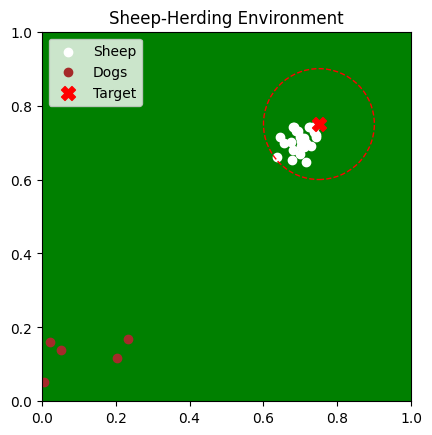

In [22]:
test_env = SheepDogEnv(render_mode="rgb_array")
model = PPO.load("ppo_sheep_dog")
obs, info=test_env.reset()
done= False
truncated = False
obs= test_env.reset()
frames=[]

obs = test_env._get_observation()
while not done and not truncated:
    action = model.predict(obs)
    obs, reward, done, truncated , info = test_env.step(action[0])
    frame = test_env.render()
    frames.append(frame)
    test_env.render()
test_env.close()
imageio.mimsave("Sheep-Herding.gif", frames, fps=30)